In [ ]:
# ============================================================
#        FERTILIZER RECOMMENDATION — ADVANCED TUNING
#        Multi-Output Regression (RandomForest, ExtraTrees, XGBoost)
#
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score, mean_squared_error

from xgboost import XGBRegressor
import joblib


# ============================================================
# 1. LOAD DATASET
# ------------------------------------------------------------
df = pd.read_csv("Nutrient_recommendation.csv")
df.head()

# ============================================================
# 2. ENCODE CROP
# ------------------------------------------------------------
enc = LabelEncoder()
df["Crop"] = enc.fit_transform(df["Crop"])

# ============================================================
# 3. SELECT FEATURES & TARGETS
# ------------------------------------------------------------
X = df[["Crop", "Temperature", "Humidity", "Rainfall"]]
y = df[["Label_N", "Label_P", "Label_K"]]

# ============================================================
# 4. TRAIN-TEST SPLIT
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================================================
# 5. SCALING
# ------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ============================================================
# 6. TUNING: RANDOM FOREST
# ------------------------------------------------------------
print("\n======================================")
print("  TUNING RANDOM FOREST...")
print("======================================")

rf = RandomForestRegressor(random_state=42)
rf_multi = MultiOutputRegressor(rf)

rf_params = {
    "estimator__n_estimators": [300, 500, 700, 900],
    "estimator__max_depth": [None, 10, 20, 30],
    "estimator__min_samples_split": [2, 5, 10],
    "estimator__min_samples_leaf": [1, 2, 4],
    "estimator__max_features": ["auto", "sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    rf_multi,
    rf_params,
    n_iter=15,
    scoring="r2",
    cv=3,
    verbose=1,
    n_jobs=-1
)

rf_search.fit(X_train_scaled, y_train)
rf_best = rf_search.best_estimator_

rf_pred = rf_best.predict(X_test_scaled)
rf_r2 = r2_score(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)

print("\n----- RANDOM FOREST RESULTS -----")
print("Best Params:", rf_search.best_params_)
print("R2 Score:", rf_r2)
print("MSE:", rf_mse)


# ============================================================
# 7. TUNING: EXTRA TREES
# ------------------------------------------------------------
print("\n======================================")
print("  TUNING EXTRA TREES...")
print("======================================")

et = ExtraTreesRegressor(random_state=42)
et_multi = MultiOutputRegressor(et)

et_params = {
    "estimator__n_estimators": [300, 500, 800, 1000],
    "estimator__max_depth": [None, 10, 20, 30],
    "estimator__min_samples_split": [2, 5, 10],
    "estimator__min_samples_leaf": [1, 2, 4],
    "estimator__max_features": ["auto", "sqrt", "log2"]
}

et_search = RandomizedSearchCV(
    et_multi,
    et_params,
    n_iter=15,
    scoring="r2",
    cv=3,
    verbose=1,
    n_jobs=-1
)

et_search.fit(X_train_scaled, y_train)
et_best = et_search.best_estimator_

et_pred = et_best.predict(X_test_scaled)
et_r2 = r2_score(y_test, et_pred)
et_mse = mean_squared_error(y_test, et_pred)

print("\n------ EXTRA TREES RESULTS ------")
print("Best Params:", et_search.best_params_)
print("R2 Score:", et_r2)
print("MSE:", et_mse)


# ============================================================
# 8. TUNING: XGBOOST
# ------------------------------------------------------------
print("\n======================================")
print("  TUNING XGBOOST...")
print("======================================")

xgb = XGBRegressor(objective="reg:squarederror", random_state=42)
xgb_multi = MultiOutputRegressor(xgb)

xgb_params = {
    "estimator__n_estimators": [300, 500, 700],
    "estimator__learning_rate": [0.01, 0.05, 0.1],
    "estimator__max_depth": [4, 6, 8],
    "estimator__subsample": [0.7, 0.8, 1.0],
    "estimator__colsample_bytree": [0.7, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    xgb_multi,
    xgb_params,
    n_iter=10,
    scoring="r2",
    cv=3,
    verbose=1,
    n_jobs=-1
)

xgb_search.fit(X_train_scaled, y_train)
xgb_best = xgb_search.best_estimator_

xgb_pred = xgb_best.predict(X_test_scaled)
xgb_r2 = r2_score(y_test, xgb_pred)
xgb_mse = mean_squared_error(y_test, xgb_pred)

print("\n-------- XGBOOST RESULTS --------")
print("Best Params:", xgb_search.best_params_)
print("R2 Score:", xgb_r2)
print("MSE:", xgb_mse)


# ============================================================
# 9. AUTO-SELECT BEST MODEL
# ------------------------------------------------------------
scores = {
    "RandomForest": rf_r2,
    "ExtraTrees": et_r2,
    "XGBoost": xgb_r2
}

best_model_name = max(scores, key=scores.get)
print("\n======================================")
print("     BEST MODEL SELECTED")
print("======================================")
print("Model:", best_model_name)
print("R2 Score:", scores[best_model_name])

if best_model_name == "RandomForest":
    best_model = rf_best
elif best_model_name == "ExtraTrees":
    best_model = et_best
else:
    best_model = xgb_best


# ============================================================
# 10. SAVE MODEL + SCALER + ENCODER
# ------------------------------------------------------------
joblib.dump(best_model, "fertilizer_tuned_model.pkl")
joblib.dump(scaler, "feature_scaler.pkl")
joblib.dump(enc, "crop_label_encoder.pkl")

print("\nModel saved successfully!")


# ============================================================
# 11. FINAL PREDICTION FUNCTION
# ------------------------------------------------------------
def predict_fertilizer(S):

    crop_encoded = enc.transform([crop])[0]

    X_in = pd.DataFrame([[crop_encoded, temperature, humidity, rainfall]],
                        columns=["Crop", "Temperature", "Humidity", "Rainfall"])

    X_scaled = scaler.transform(X_in)
    result = best_model.predict(X_scaled)[0]

    return {
        "Recommended_N": round(result[0], 2),
        "Recommended_P": round(result[1], 2),
        "Recommended_K": round(result[2], 2)
    }


# ============================================================
# 12. TEST PREDICTION
# ------------------------------------------------------------
print("\nTest Prediction Example:")
print(predict_fertilizer("rice", 25, 85, 200))



  TUNING RANDOM FOREST...
Fitting 3 folds for each of 15 candidates, totalling 45 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
12 fits failed out of a total of 45.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
12 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/multioutput.py", line 274, in fit
    self.estimators_ = Parallel(n_jobs


----- RANDOM FOREST RESULTS -----
Best Params: {'estimator__n_estimators': 700, 'estimator__min_samples_split': 10, 'estimator__min_samples_leaf': 1, 'estimator__max_features': 'sqrt', 'estimator__max_depth': 10}
R2 Score: 0.9376534275731495
MSE: 74.84331218560754

  TUNING EXTRA TREES...
Fitting 3 folds for each of 15 candidates, totalling 45 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
12 fits failed out of a total of 45.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
12 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", li


------ EXTRA TREES RESULTS ------
Best Params: {'estimator__n_estimators': 300, 'estimator__min_samples_split': 2, 'estimator__min_samples_leaf': 2, 'estimator__max_features': 'sqrt', 'estimator__max_depth': None}
R2 Score: 0.9375224136703425
MSE: 75.1616938612456

  TUNING XGBOOST...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

-------- XGBOOST RESULTS --------
Best Params: {'estimator__subsample': 0.7, 'estimator__n_estimators': 700, 'estimator__max_depth': 6, 'estimator__learning_rate': 0.01, 'estimator__colsample_bytree': 1.0}
R2 Score: 0.9348801970481873
MSE: 77.88996124267578

     BEST MODEL SELECTED
Model: RandomForest
R2 Score: 0.9376534275731495

Model saved successfully!

Test Prediction Example:
{'Recommended_N': np.float64(78.25), 'Recommended_P': np.float64(41.8), 'Recommended_K': np.float64(40.36)}


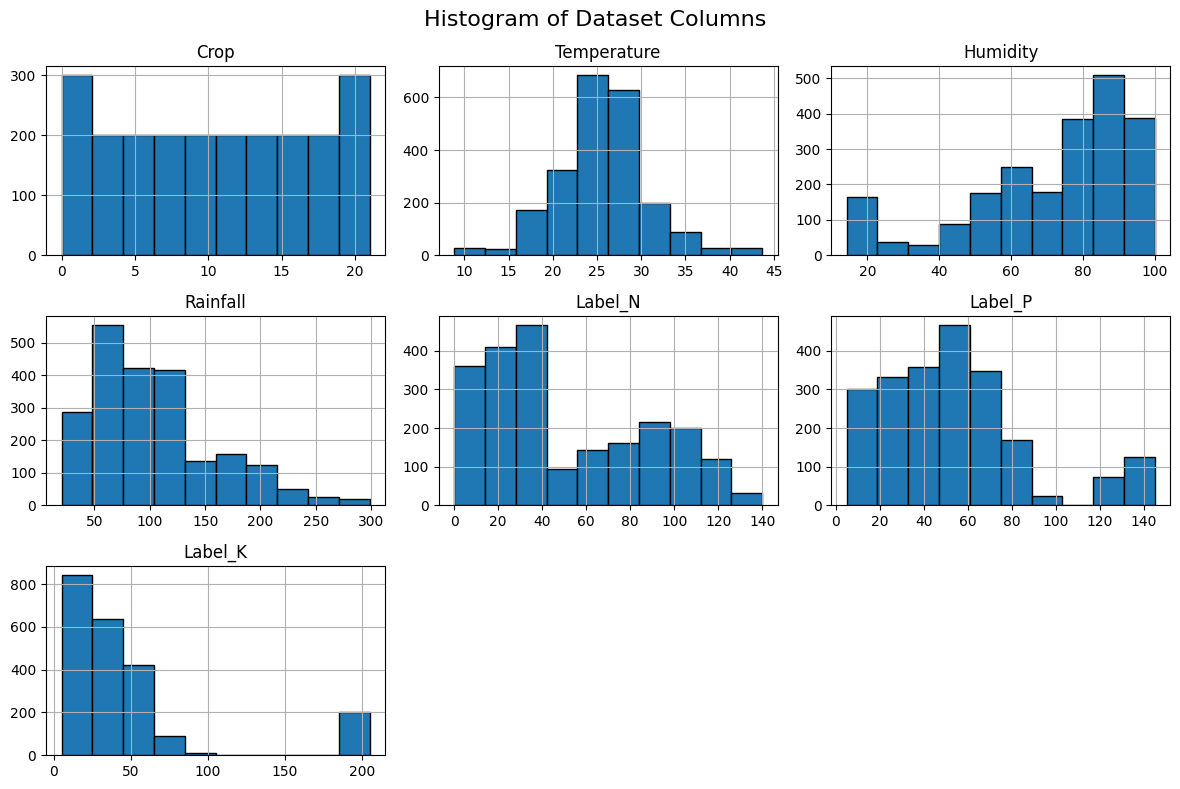

In [ ]:
# ============================================================
#   HISTOGRAMS OF ALL COLUMNS
# ============================================================
import matplotlib.pyplot as plt

df.hist(figsize=(12, 8), edgecolor='black')
plt.suptitle("Histogram of Dataset Columns", fontsize=16)
plt.tight_layout()
plt.show()


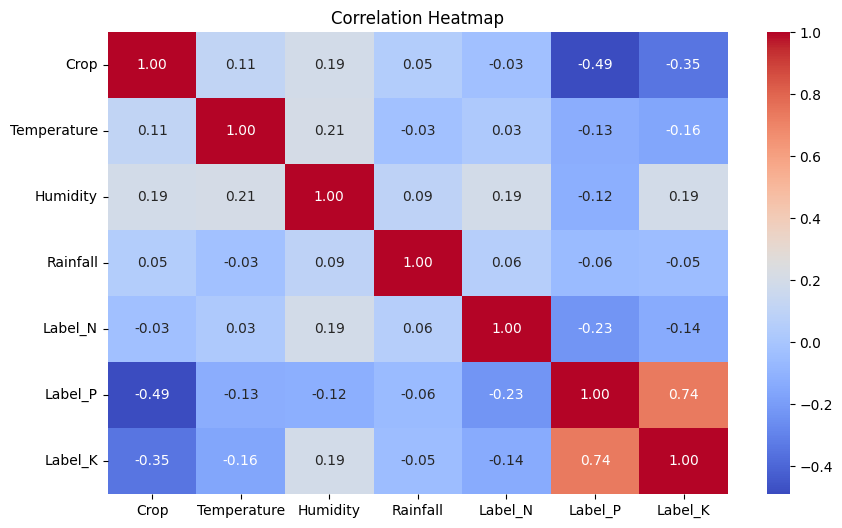

In [ ]:
# ============================================================
#   CORRELATION HEATMAP
# ============================================================
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


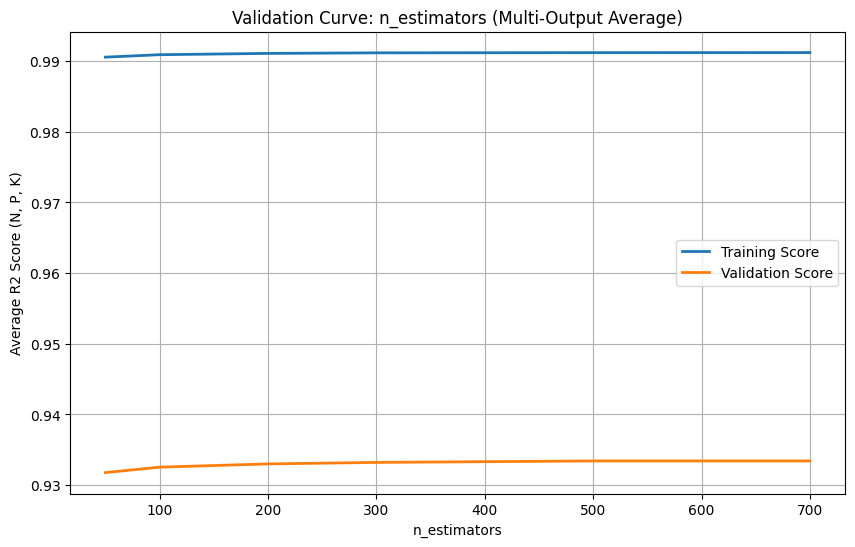

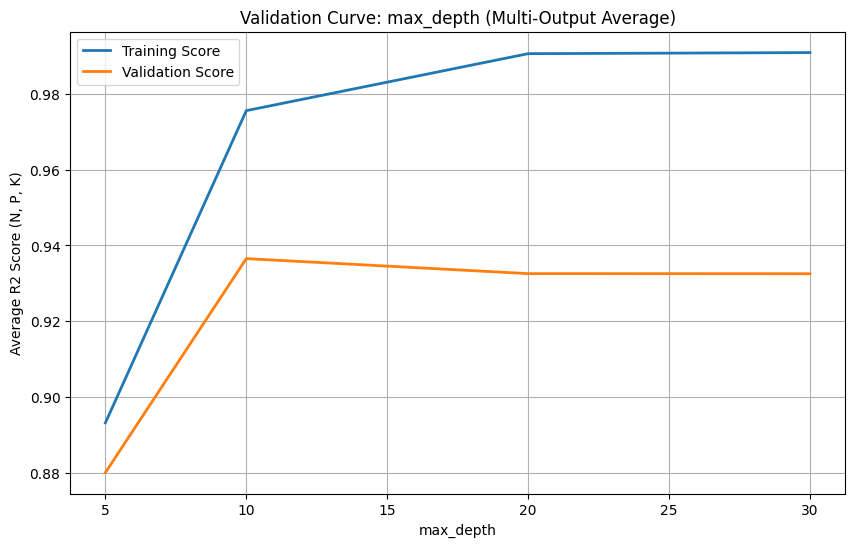

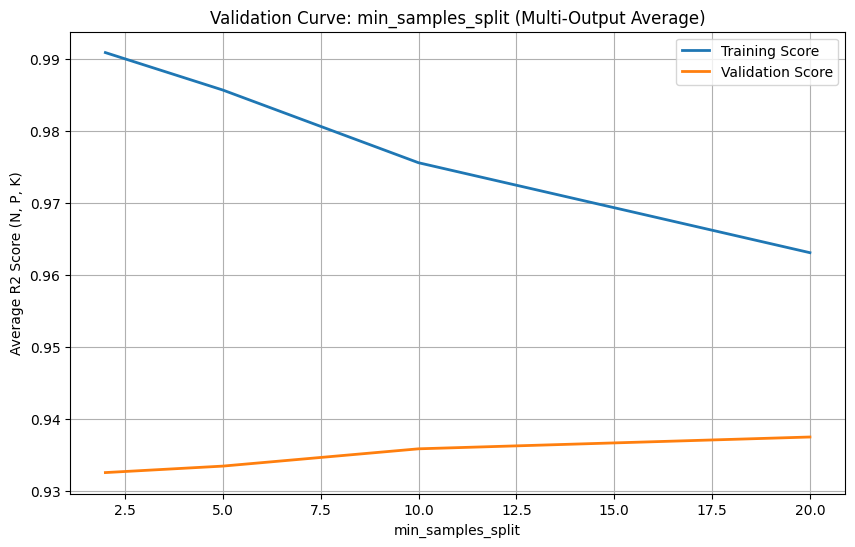

In [ ]:
# ============================================================
#   MORE ACCURATE VALIDATION CURVE (Multi-Output)
#   Shows model performance across 3 nutrient labels
# ============================================================

from sklearn.model_selection import validation_curve
import numpy as np
import matplotlib.pyplot as plt

def multi_output_validation_curve(model, param_name, param_range):

    train_scores_list = []
    test_scores_list = []

    for label in ["Label_N", "Label_P", "Label_K"]:
        train_scores, test_scores = validation_curve(
            model,
            X_train_scaled,
            y_train[label],
            param_name=param_name,
            param_range=param_range,
            scoring="r2",
            cv=3,
            n_jobs=-1
        )
        train_scores_list.append(train_scores)
        test_scores_list.append(test_scores)

    # Average scores across N, P, K
    train_mean = np.mean([scores.mean(axis=1) for scores in train_scores_list], axis=0)
    test_mean = np.mean([scores.mean(axis=1) for scores in test_scores_list], axis=0)

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(param_range, train_mean, label="Training Score", linewidth=2)
    plt.plot(param_range, test_mean, label="Validation Score", linewidth=2)
    plt.xlabel(param_name)
    plt.ylabel("Average R2 Score (N, P, K)")
    plt.title(f"Validation Curve: {param_name} (Multi-Output Average)")
    plt.legend()
    plt.grid(True)
    plt.show()


# ------------------------------------------------------------
# Example 1: n_estimators
# ------------------------------------------------------------

param_range = [50, 100, 200, 300, 500, 700]
base_rf = RandomForestRegressor(random_state=42)

multi_output_validation_curve(
    model=base_rf,
    param_name="n_estimators",
    param_range=param_range
)

# ------------------------------------------------------------
# Example 2: max_depth
# ------------------------------------------------------------

param_range = [None, 5, 10, 20, 30]

multi_output_validation_curve(
    model=base_rf,
    param_name="max_depth",
    param_range=param_range
)

# ------------------------------------------------------------
# Example 3: min_samples_split
# ------------------------------------------------------------

param_range = [2, 5, 10, 20]

multi_output_validation_curve(
    model=base_rf,
    param_name="min_samples_split",
    param_range=param_range
)


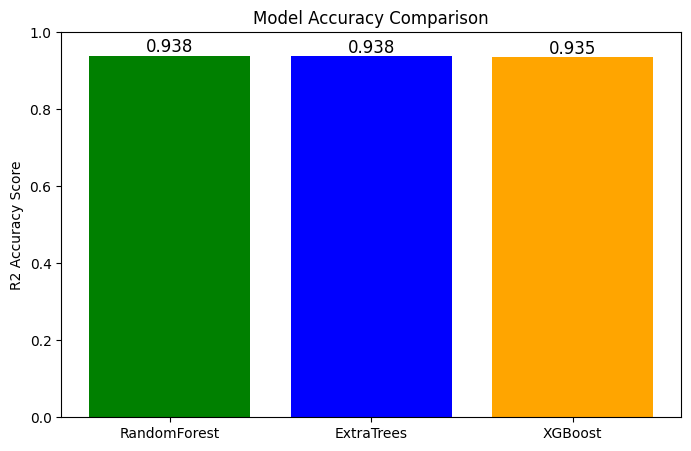

In [ ]:
scores = {
    "RandomForest": rf_r2,
    "ExtraTrees": et_r2,
    "XGBoost": xgb_r2
}
# ============================================================
#   MODEL ACCURACY COMPARISON BAR CHART
# ============================================================
plt.figure(figsize=(8, 5))
plt.bar(scores.keys(), scores.values(), color=['green', 'blue', 'orange'])
plt.ylabel("R2 Accuracy Score")
plt.title("Model Accuracy Comparison")
plt.ylim(0.0, 1.0)
for i, v in enumerate(scores.values()):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=12)
plt.show()


In [ ]:
print(predict_fertilizer("rice", 25, 85, 100))

{'Recommended_N': np.float64(76.04), 'Recommended_P': np.float64(21.05), 'Recommended_K': np.float64(41.32)}
